Global Mobile Money Account Adoption Prediction Using Machine Learning

Student Name: Vijayakumar V
Batch:DS-ANB01

1.Problem Definition
Mobile money services have become an important driver of financial inclusion worldwide. Understanding the factors influencing mobile money account ownership can help governments, financial institutions, and policymakers design strategies to improve access to digital financial services. The objective of this project is to analyze demographic and socioeconomic factors affecting mobile money account ownership and predict the mobile money adoption rate (OBS_VALUE) using machine learning models.

2.Business Objective
The objective of this project is to analyze demographic and socioeconomic factors affecting mobile money account ownership and develop a machine learning model to predict the mobile money adoption rate using World Bank Global Findex data. Example: • Analyze patterns of mobile money adoption across countries and demographic groups. • Identify key factors influencing mobile money account ownership. • Build and compare multiple regression models. • Select the best-performing model. • Deploy the model using FastAPI for real-time predictions.

3.Machine Learning Problem Type
• [*] Supervised Learning – Regression

4.Dataset Source
DatasetSource: https://www.google.com/url?q=https%3A%2F%2Fdata360.worldbank.org%2Fen%2Findicator%2FWB_FINDEX_MOBILEACCOUNT_T_D

5.Dataset Description
Explain:

• Number of rows: 2513
• Number of columns:39
• Dataset purpose: To perform the Model which is to be predict the mobile money account adoption across world.
• Data collection source: World Bank Open Data

6.Target Variable (If Applicable)
Target Variable: • Name: World Bank Global Findex Mobile Money Account Dataset • Description: OBS_VALUE • Prediction Goal: Predict the mobile money account owning users.

Input Features
• Country
• Year
• Gender
• Age Group
• Urbanization
• Income Group
• Employment Status
• Education Level

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.linear_model import LinearRegression,Ridge,Lasso
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [2]:
df = pd.read_csv("WB_FINDEX_MOBILEACCOUNT_T_D.csv")

In [3]:
print(df.shape)

(2513, 39)


In [4]:
df.head()

,STRUCTURE,STRUCTURE_ID,ACTION,FREQ,REF_AREA,INDICATOR,SEX,AGE,URBANISATION,UNIT_MEASURE,...,COMP_BREAKDOWN_1_LABEL,COMP_BREAKDOWN_2_LABEL,COMP_BREAKDOWN_3_LABEL,UNIT_TYPE_LABEL,DATABASE_ID_LABEL,TIME_FORMAT_LABEL,UNIT_MULT_LABEL,OBS_STATUS_LABEL,DATA_SOURCE_LABEL,OBS_CONF_LABEL
0,datastructure,WB.DATA360:DS_DATA360(1.3),I,A3,AFG,WB_FINDEX_MOBILEACCOUNT_T_D,_T,Y_GE15,_T,PT_RESP,...,Total,Total,Total,Ratio,Global Findex Database,CCYY,Units,Normal value,Global Findex Database,Public
1,datastructure,WB.DATA360:DS_DATA360(1.3),I,A3,ARG,WB_FINDEX_MOBILEACCOUNT_T_D,_T,Y_GE15,_T,PT_RESP,...,Total,Total,Total,Ratio,Global Findex Database,CCYY,Units,Normal value,Global Findex Database,Public
2,datastructure,WB.DATA360:DS_DATA360(1.3),I,A3,ARM,WB_FINDEX_MOBILEACCOUNT_T_D,_T,Y_GE15,_T,PT_RESP,...,Total,Total,Total,Ratio,Global Findex Database,CCYY,Units,Normal value,Global Findex Database,Public
3,datastructure,WB.DATA360:DS_DATA360(1.3),I,A3,BGD,WB_FINDEX_MOBILEACCOUNT_T_D,_T,Y_GE15,_T,PT_RESP,...,Total,Total,Total,Ratio,Global Findex Database,CCYY,Units,Normal value,Global Findex Database,Public
4,datastructure,WB.DATA360:DS_DATA360(1.3),I,A3,BEN,WB_FINDEX_MOBILEACCOUNT_T_D,_T,Y_GE15,_T,PT_RESP,...,Total,Total,Total,Ratio,Global Findex Database,CCYY,Units,Normal value,Global Findex Database,Public


In [5]:
df.columns

Index(['STRUCTURE', 'STRUCTURE_ID', 'ACTION', 'FREQ', 'REF_AREA', 'INDICATOR',
       'SEX', 'AGE', 'URBANISATION', 'UNIT_MEASURE', 'COMP_BREAKDOWN_1',
       'COMP_BREAKDOWN_2', 'COMP_BREAKDOWN_3', 'TIME_PERIOD', 'UNIT_TYPE',
       'DATABASE_ID', 'TIME_FORMAT', 'UNIT_MULT', 'DATA_SOURCE', 'OBS_CONF',
       'OBS_VALUE', 'OBS_STATUS', 'FREQ_LABEL', 'REF_AREA_LABEL',
       'INDICATOR_LABEL', 'SEX_LABEL', 'AGE_LABEL', 'URBANISATION_LABEL',
       'UNIT_MEASURE_LABEL', 'COMP_BREAKDOWN_1_LABEL',
       'COMP_BREAKDOWN_2_LABEL', 'COMP_BREAKDOWN_3_LABEL', 'UNIT_TYPE_LABEL',
       'DATABASE_ID_LABEL', 'TIME_FORMAT_LABEL', 'UNIT_MULT_LABEL',
       'OBS_STATUS_LABEL', 'DATA_SOURCE_LABEL', 'OBS_CONF_LABEL'],
      dtype='str')

In [6]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 2513 entries, 0 to 2512
Data columns (total 39 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   STRUCTURE               2513 non-null   str    
 1   STRUCTURE_ID            2513 non-null   str    
 2   ACTION                  2513 non-null   str    
 3   FREQ                    2513 non-null   str    
 4   REF_AREA                2513 non-null   str    
 5   INDICATOR               2513 non-null   str    
 6   SEX                     2513 non-null   str    
 7   AGE                     2513 non-null   str    
 8   URBANISATION            2513 non-null   str    
 9   UNIT_MEASURE            2513 non-null   str    
 10  COMP_BREAKDOWN_1        2513 non-null   str    
 11  COMP_BREAKDOWN_2        2513 non-null   str    
 12  COMP_BREAKDOWN_3        2513 non-null   str    
 13  TIME_PERIOD             2513 non-null   int64  
 14  UNIT_TYPE               2513 non-null   str    
 15

In [7]:
print(df.dtypes)

STRUCTURE                     str
STRUCTURE_ID                  str
ACTION                        str
FREQ                          str
REF_AREA                      str
INDICATOR                     str
SEX                           str
AGE                           str
URBANISATION                  str
UNIT_MEASURE                  str
COMP_BREAKDOWN_1              str
COMP_BREAKDOWN_2              str
COMP_BREAKDOWN_3              str
TIME_PERIOD                 int64
UNIT_TYPE                     str
DATABASE_ID                   str
TIME_FORMAT                 int64
UNIT_MULT                   int64
DATA_SOURCE                   str
OBS_CONF                      str
OBS_VALUE                 float64
OBS_STATUS                    str
FREQ_LABEL                    str
REF_AREA_LABEL                str
INDICATOR_LABEL               str
SEX_LABEL                     str
AGE_LABEL                     str
URBANISATION_LABEL            str
UNIT_MEASURE_LABEL            str
COMP_BREAKDOWN

In [8]:
df[["TIME_PERIOD","OBS_VALUE"]].describe()

,TIME_PERIOD,OBS_VALUE
count,2513.000000,2513.000000
mean,2020.814564,28.369588
std,3.410572,18.767312
min,2014.000000,0.000000
25%,2017.000000,13.529876
50%,2021.000000,24.210873
75%,2024.000000,40.548937
max,2024.000000,93.938767


Interpretation
1.TIME_PERIOD - Most observations are around 2021.
2.OBS_VALUE - Average mobile money ownership is 28.37%.
3.Min OBS_VALUE - Some populations have no mobile account ownership.
4.Max OBS_VALUE- Some populations have very high adoption.

Correlation

In [9]:
corr = df[["TIME_PERIOD","OBS_VALUE"]].corr()

print(corr)

             TIME_PERIOD  OBS_VALUE
TIME_PERIOD     1.000000   0.303483
OBS_VALUE       0.303483   1.000000


Meaning
1.Mobile money adoption generally increases over time.
2.Relationship is positive but not very strong.

Visualization

Histogram

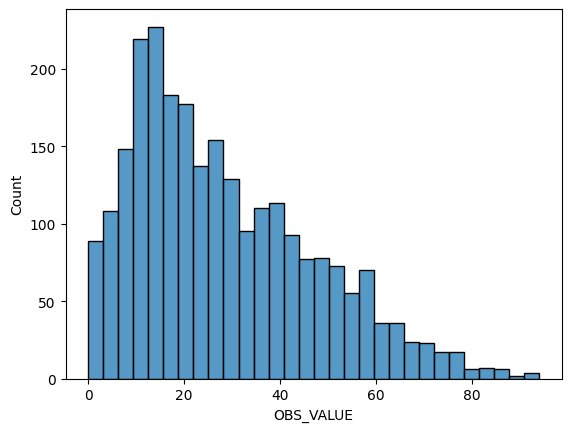

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df["OBS_VALUE"], bins=30)
plt.show()

## Observation = Distribution is right skewed

Box Plot

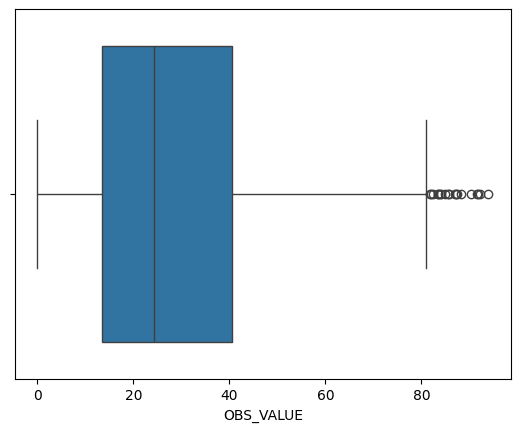

In [11]:
sns.boxplot(x=df["OBS_VALUE"])
plt.show()

## Obeservation -Some high-value outliers exist.

Trend Over time

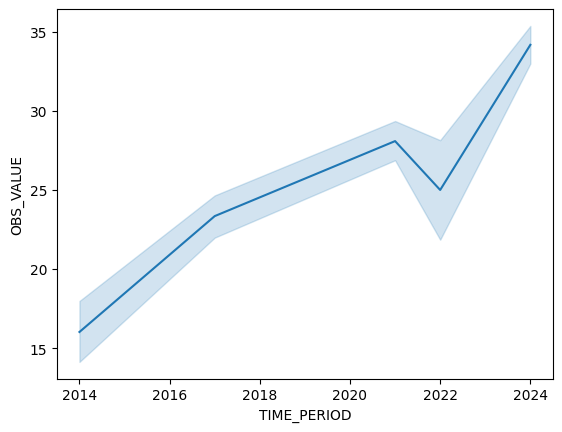

In [12]:
sns.lineplot(data=df,x="TIME_PERIOD",y="OBS_VALUE")
plt.show()

## Obeservation - Mobile account ownership rises over years.

Country comparision

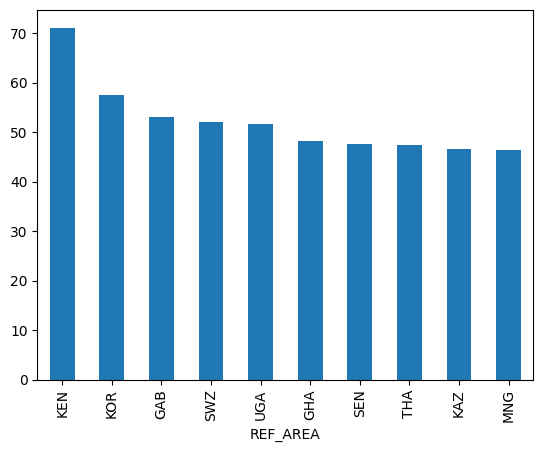

In [13]:
top = df.groupby("REF_AREA")["OBS_VALUE"].mean().sort_values(ascending=False).head(10)

top.plot(kind="bar")
plt.show()

Gender Analysis

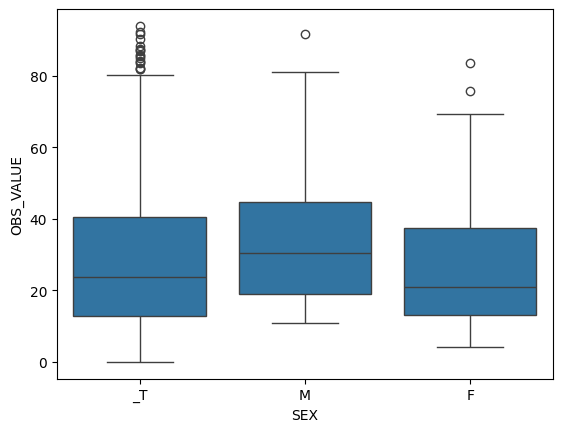

In [14]:
sns.boxplot(x="SEX",y="OBS_VALUE",data=df)
plt.show()

Urban Vs Rural

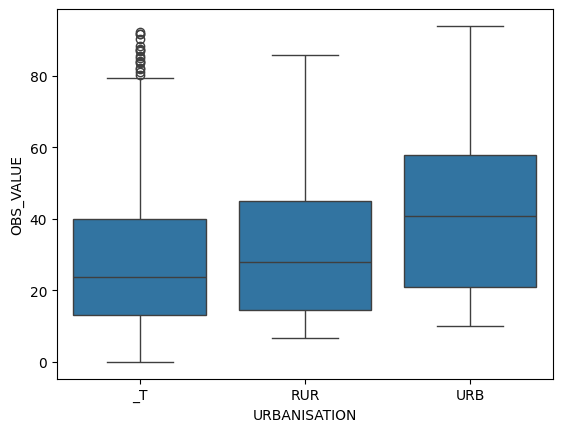

In [15]:
sns.boxplot(x="URBANISATION",y="OBS_VALUE",data=df)
plt.show()

Age Group Analysis

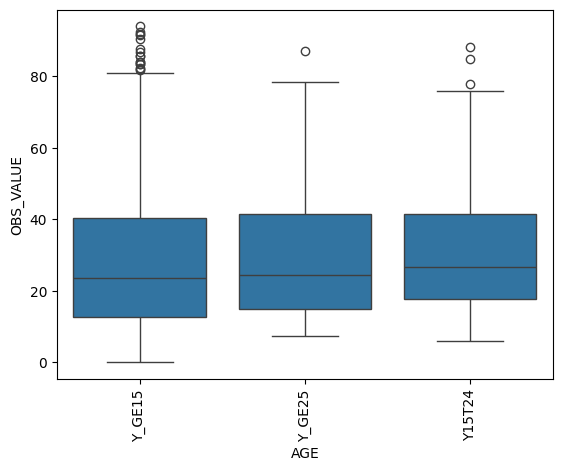

In [16]:
sns.boxplot(x="AGE",y="OBS_VALUE",data=df)
plt.xticks(rotation=90)
plt.show()

Correlation Heatmap

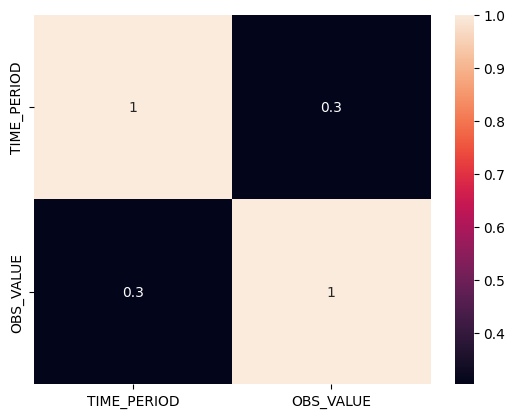

In [17]:
sns.heatmap(df[["TIME_PERIOD","OBS_VALUE"]].corr(),annot=True)
plt.show()

Data Preprocessing

In [18]:
print("Missing Values in Each Column:")
print(df.isnull().sum())

Missing Values in Each Column:
STRUCTURE                 0
STRUCTURE_ID              0
ACTION                    0
FREQ                      0
REF_AREA                  0
INDICATOR                 0
SEX                       0
AGE                       0
URBANISATION              0
UNIT_MEASURE              0
COMP_BREAKDOWN_1          0
COMP_BREAKDOWN_2          0
COMP_BREAKDOWN_3          0
TIME_PERIOD               0
UNIT_TYPE                 0
DATABASE_ID               0
TIME_FORMAT               0
UNIT_MULT                 0
DATA_SOURCE               0
OBS_CONF                  0
OBS_VALUE                 0
OBS_STATUS                0
FREQ_LABEL                0
REF_AREA_LABEL            0
INDICATOR_LABEL           0
SEX_LABEL                 0
AGE_LABEL                 0
URBANISATION_LABEL        0
UNIT_MEASURE_LABEL        0
COMP_BREAKDOWN_1_LABEL    0
COMP_BREAKDOWN_2_LABEL    0
COMP_BREAKDOWN_3_LABEL    0
UNIT_TYPE_LABEL           0
DATABASE_ID_LABEL         0
TIME_FORMAT_LABEL

In [19]:
print("Before:", df.shape)
df = df.drop_duplicates()
print("After:", df.shape)

Before: (2513, 39)
After: (2513, 39)


Outlier Analysis

Do NOT remove outliers.

Reason:

1.Values represent real country-level differences.
2.Removing them loses information.
3.Eg,,.. Kenya is actually one of the world's leaders in mobile money adoption and 92% is not a mistake.

Skewness

Recommendation
  Do NOT transform target.

Reason:
1.Target variable should remain interpretable.
2.Tree models handle skewness well.
3.TIME_PERIOD shows approximately symmetric distribution and therefore does not require skewness transformation.

One-Hot Encoding

In [20]:
OneHotEncoder(handle_unknown="ignore")

###Now the model can learn country-level differences.

,"categories categories: 'auto' or a list of array-like, default='auto'Categories (unique values) per feature:- 'auto' : Determine categories automatically from the training data.- list : ``categories[i]`` holds the categories expected in the ith column. The passed categories should not mix strings and numeric values within a single feature, and should be sorted in case of numeric values.The used categories can be found in the ``categories_`` attribute... versionadded:: 0.20",'auto'
,"drop drop: {'first', 'if_binary'} or an array-like of shape (n_features,), default=NoneSpecifies a methodology to use to drop one of the categories perfeature. This is useful in situations where perfectly collinearfeatures cause problems, such as when feeding the resulting datainto an unregularized linear regression model.However, dropping one category breaks the symmetry of the originalrepresentation and can therefore induce a bias in downstream models,for instance for penalized linear classification or regression models.- None : retain all features (the default).- 'first' : drop the first category in each feature. If only one category is present, the feature will be dropped entirely.- 'if_binary' : drop the first category in each feature with two categories. Features with 1 or more than 2 categories are left intact.- array : ``drop[i]`` is the category in feature ``X[:, i]`` that should be dropped.When `max_categories` or `min_frequency` is configured to groupinfrequent categories, the dropping behavior is handled after thegrouping... versionadded:: 0.21 The parameter `drop` was added in 0.21... versionchanged:: 0.23 The option `drop='if_binary'` was added in 0.23... versionchanged:: 1.1 Support for dropping infrequent categories.",None
,"sparse_output sparse_output: bool, default=TrueWhen ``True``, it returns a :class:`scipy.sparse.csr_matrix`,i.e. a sparse matrix in ""Compressed Sparse Row"" (CSR) format... versionadded:: 1.2 `sparse` was renamed to `sparse_output`",True
,"dtype dtype: number type, default=np.float64Desired dtype of output.",<class 'numpy.float64'>
,"handle_unknown handle_unknown: {'error', 'ignore', 'infrequent_if_exist', 'warn'}, default='error'Specifies the way unknown categories are handled during :meth:`transform`.- 'error' : Raise an error if an unknown category is present during transform.- 'ignore' : When an unknown category is encountered during transform, the resulting one-hot encoded columns for this feature will be all zeros. In the inverse transform, an unknown category will be denoted as None.- 'infrequent_if_exist' : When an unknown category is encountered during transform, the resulting one-hot encoded columns for this feature will map to the infrequent category if it exists. The infrequent category will be mapped to the last position in the encoding. During inverse transform, an unknown category will be mapped to the category denoted `'infrequent'` if it exists. If the `'infrequent'` category does not exist, then :meth:`transform` and :meth:`inverse_transform` will handle an unknown category as with `handle_unknown='ignore'`. Infrequent categories exist based on `min_frequency` and `max_categories`. Read more in the :ref:`User Guide `.- 'warn' : When an unknown category is encountered during transform a warning is issued, and the encoding then proceeds as described for `handle_unknown=""infrequent_if_exist""`... versionchanged:: 1.1 `'infrequent_if_exist'` was added to automatically handle unknown categories and infrequent categories... versionadded:: 1.6 The option `""warn""` was added in 1.6.",'ignore'
,"min_frequency min_frequency: int or float, default=NoneSpecifies the minimum frequency below which a category will beconsidered infrequent.- If `int`, categories with a smaller cardinality will be considered infrequent.- If `float`, categories with a smaller cardinality than `min_frequency * n_samples` will be considered infrequent... versionadded:: 1.1 Read more in the :ref:`User Guide `.",None
,"max_categ

Feature Scaling

In [21]:
numeric_features = ["TIME_PERIOD"]
categorical_features = [
    "REF_AREA",
    "SEX",
    "AGE",
    "URBANISATION",
    "COMP_BREAKDOWN_1",
    "COMP_BREAKDOWN_2",
    "COMP_BREAKDOWN_3"
]

In [22]:
X = df.drop("OBS_VALUE", axis=1)
y = df["OBS_VALUE"]

Train and Evaluate Models

In [23]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=42)

print(X_train.shape)
print(X_test.shape)

(2010, 38)
(503, 38)


Preprocessing Pipelines

Numberical pipeline

In [24]:
numeric_transformer = Pipeline([("imputer",SimpleImputer(strategy="median")),("scaler",StandardScaler())])

Categorical Pipeline

In [25]:
categorical_transformer = Pipeline([("imputer",SimpleImputer(strategy="most_frequent")),("encoder",OneHotEncoder(handle_unknown="ignore"))])

ColumnTransformer

In [26]:
preprocessor = ColumnTransformer(transformers=[("num",numeric_transformer,numeric_features),("cat",categorical_transformer,categorical_features)])

Build Models

In [27]:
models = {"Linear Regression":LinearRegression(),"Ridge Regression":Ridge(alpha=1.0),"Lasso Regression":Lasso(alpha=0.01)}

In [28]:
results = []

for name, model in models.items():

    pipe = Pipeline([

        (
            "preprocessor",
            preprocessor
        ),

        (
            "model",
            model
        )
    ])

    pipe.fit(
        X_train,
        y_train
    )

    y_pred = pipe.predict(
        X_test
    )

    mae = mean_absolute_error(
        y_test,
        y_pred
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_test,
            y_pred
        )
    )

    r2 = r2_score(
        y_test,
        y_pred
    )

    results.append([
        name,
        mae,
        rmse,
        r2
    ])

Compare Models

In [30]:
results_df = pd.DataFrame(

    results,

    columns=[
        "Model",
        "MAE",
        "RMSE",
        "R2"
    ]
)

results_df.sort_values(
    by="R2",
    ascending=False )

,Model,MAE,RMSE,R2
0,Linear Regression,6.164803,8.194267,0.817279
1,Ridge Regression,6.243979,8.277722,0.813538
2,Lasso Regression,6.381707,8.410112,0.807526


Overfitting / Underfitting Discussion

Linear Regression : Possible underfitting.
Polynomial Regression:Possible overfitting.
Ridge Regression : Balanced bias-variance tradeoff & Recommended.
Lasso Regression :May slightly underfit if too many variables are removed.

Select Best Model

In [31]:
model = Pipeline([("preprocessor",preprocessor),("model",Ridge(alpha=1.0))])

model.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

Final Model Recommended

✅ Ridge Regression

Reason:

1.Large number of encoded categorical features
2.Handles correlated variables well
3.More stable than Linear Regression
4.Less overfitting risk than Polynomial Regression
5.Usually produces better generalization
6.82% of variation in mobile money account ownership is explained by the model.

In [33]:
import joblib

In [34]:
joblib.dump(model,"mobile_account_model.pkl")

print("Model Saved Successfully")

Model Saved Successfully
